---

# BAR CHARTS

---

In [1]:
import pandas as pd
import numpy as np

In [2]:
retail = pd.read_csv('Data/retail_2016_2017.csv', parse_dates=['date'])

retail = (retail
    .query("family in ['DAIRY', 'POULTRY'] and date.dt.year == 2016 and date.dt.month == 3")
    .pivot_table(index=retail['date'].dt.date, columns='family', values='sales', aggfunc='sum')
    .astype('int')
)

retail.head()

family,DAIRY,POULTRY
date,,
2016-03-01,50067,25350
2016-03-02,49731,21372
2016-03-03,38585,17376
2016-03-04,44098,27077
2016-03-05,61647,26651


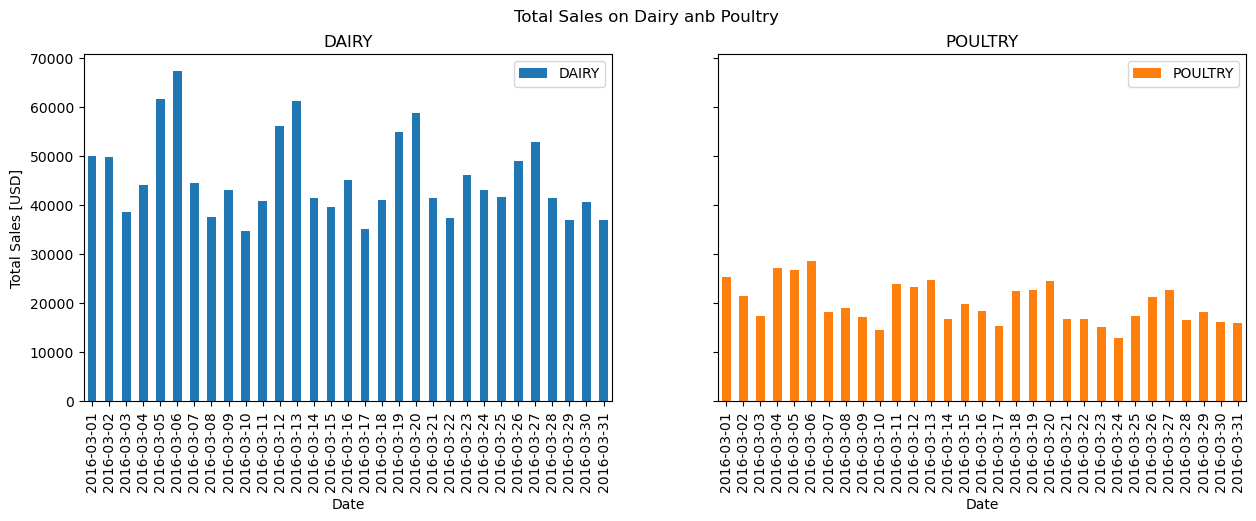

In [3]:
retail.plot.bar(
    figsize=(15,4.5),
    subplots=True,
    layout=(1,2),
    sharey=True,
    title=('Total Sales on Dairy anb Poultry'),
    xlabel=('Date'),
    ylabel=('Total Sales [USD]'),
    rot=90
);

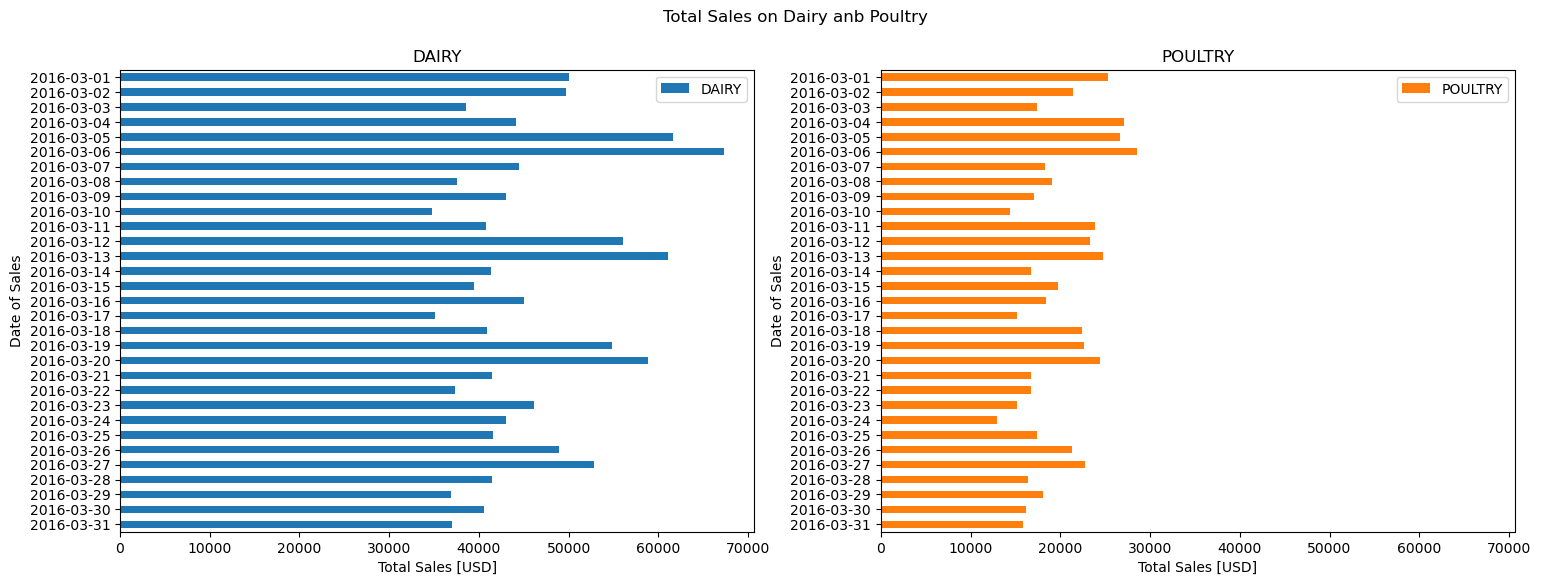

In [4]:
retail[::-1].plot.barh(
    figsize=(18, 6),
    subplots=True,
    layout=(1,2),
    sharey=False,
    title=('Total Sales on Dairy anb Poultry'),
    xlabel=('Total Sales [USD]'),
    ylabel=('Date of Sales'),
);

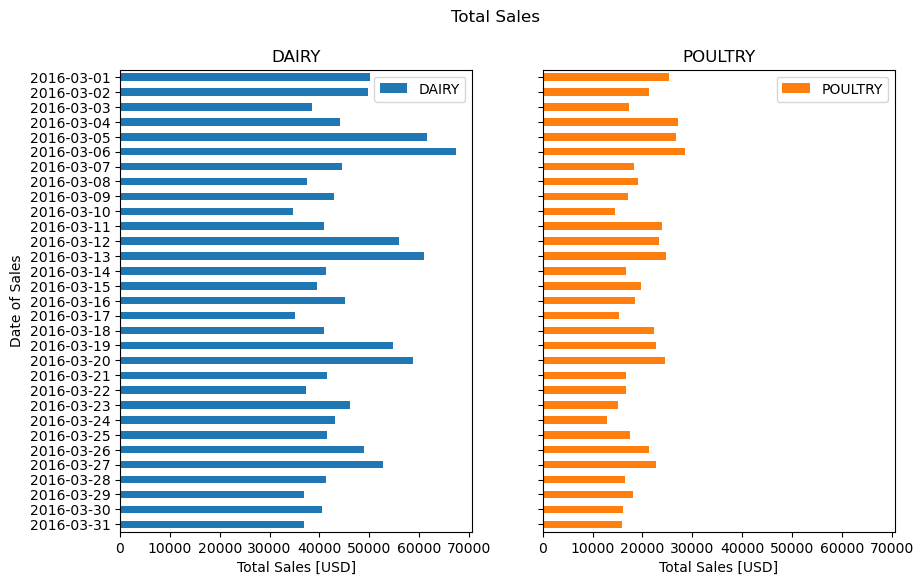

In [5]:
retail[::-1].plot.barh(
    figsize=(10, 6),       # argumento
    subplots=True,         # argumento
    layout=(1, 2),         # argumento
    sharey=True,           # argumento
    title='Total Sales',   # argumento
    xlabel='Total Sales [USD]',   # argumento
    ylabel='Date of Sales',       # argumento
);

>---
>`Line Charts` are used for showing trends and changes over time.
>- They are the default chart type when using `.plot()`
>- Note that the X-Axis should be continuous.

<br><br>

>---
>`Bar Charts` are used for making comparisons with categorical data.
>- You'll typically aggregate the data by category first.
>- `.bar()` will return a vertical bar chart (*or column chart*)
>- `.barh()` will return a horizontal bar chart (* or row chart*)
>   - NOTE: the horizontal bar charts are **sorted in reverse order**
> 


---

# LABORATORY

In [6]:
transactions = pd.read_csv('Data/transactions.csv', parse_dates=['date'])

# Let's see the total sum of transactions per day
plot_df = transactions.groupby('store_nbr').agg({'transactions':['sum']}).droplevel(0, axis=1)
plot_df.head()

,sum
store_nbr,
1,2553963
2,3219901
3,5366350
4,2519007
5,2347877


In [7]:
plot_df.columns

Index(['sum'], dtype='object')

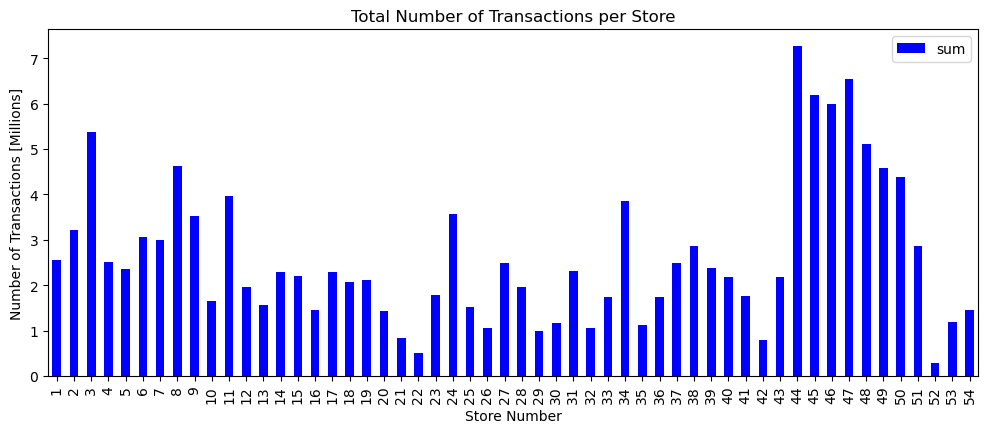

In [8]:
(plot_df/1_000_000).plot.bar(
    figsize=(12,4.5),
    title="Total Number of Transactions per Store",
    xlabel='Store Number',
    ylabel='Number of Transactions [Millions]',
    cmap='winter'
);

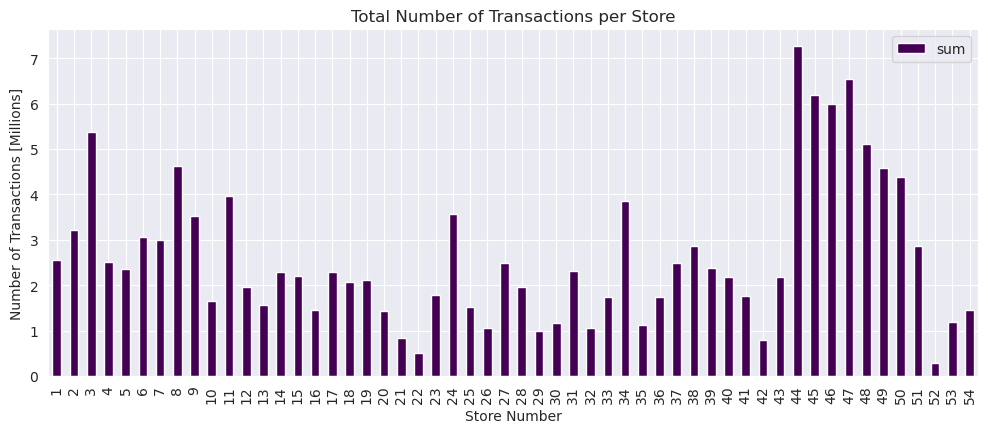

In [9]:
import seaborn as sns

sns.set_style('darkgrid')

(plot_df/1_000_000).plot.bar(
    figsize=(12,4.5),
    title="Total Number of Transactions per Store",
    xlabel='Store Number',
    ylabel='Number of Transactions [Millions]',
    cmap='viridis'
);

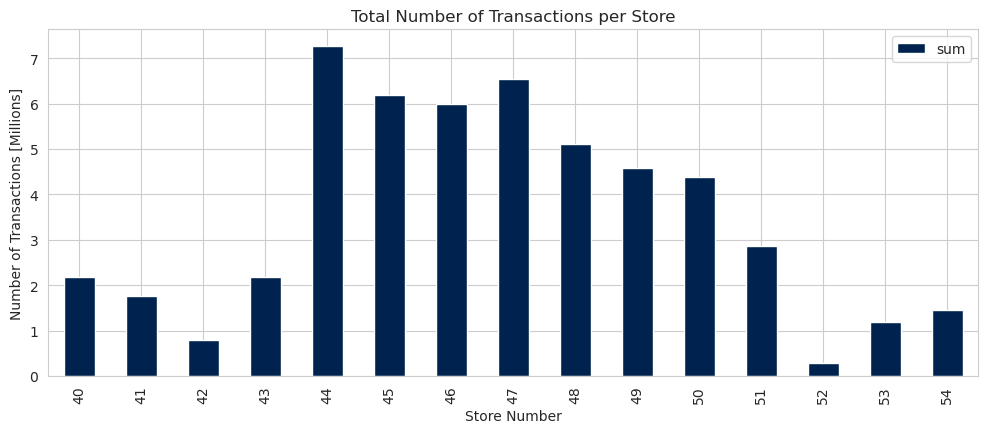

In [10]:
sns.set_style('whitegrid')

(plot_df/1_000_000).iloc[39:].plot.bar(
    figsize=(12,4.5),
    title="Total Number of Transactions per Store",
    xlabel='Store Number',
    ylabel='Number of Transactions [Millions]',
    cmap='cividis'
);